# IMPORT LIBRARIES

In [ ]:
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt
import re
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms as transforms

In [ ]:
base_path= '/content/drive/MyDrive/roco-content'
data_splits = ['train', 'test', 'validation']
subfolders = ['radiology', 'non-radiology']
sample_size_per_category = 8000
data= []


MAKING A DATASET

In [ ]:
for split in data_splits:
    for subfolder in subfolders:
        caption_file = os.path.join(base_path, split, subfolder, 'captions.txt')
        image_folder = os.path.join( base_path, split, subfolder, 'images')

        # Read a subset of captions
        with open(caption_file, 'r') as file:
            # Collect only the first `sample_size_per_category` captions
            for i, line in enumerate(file):


                match = re.match(r"^(\S+)\s+(.*)$", line.strip())
                if match:
                    image_id = match.group(1)
                    caption = match.group(2)
                    image_path = os.path.join(image_folder, f"{image_id}.jpg")


                    data.append({
                        'image_id': image_id,
                        'caption': caption,
                        'label': subfolder,
                        'split': split,
                        'image_path': image_path
                    })

In [ ]:
sample_df = pd.DataFrame(data)
print("Sample DataFrame created with columns:", sample_df.columns)

Sample DataFrame created with columns: Index(['image_id', 'caption', 'label', 'split', 'image_path'], dtype='object')


In [ ]:
print(sample_df.head(5))

     image_id                                            caption      label  \
0  ROCO_00002  Computed tomography scan in axial view showing...  radiology   
1  ROCO_00003  Bacterial contamination occurred after complet...  radiology   
2  ROCO_00004  The patient had residual paralysis of the hand...  radiology   
3  ROCO_00005      Panoramic radiograph after immediate loading.  radiology   
4  ROCO_00007  Plain abdomen x-ray: Multiple air levels at th...  radiology   

   split                                         image_path  
0  train  /content/drive/MyDrive/roco-content/train/radi...  
1  train  /content/drive/MyDrive/roco-content/train/radi...  
2  train  /content/drive/MyDrive/roco-content/train/radi...  
3  train  /content/drive/MyDrive/roco-content/train/radi...  
4  train  /content/drive/MyDrive/roco-content/train/radi...  


In [ ]:
sample_df.tail(5)

,image_id,caption,label,split,image_path
175847,ROCO_87894,Scanning electron photomicrograph of blood cel...,non-radiology,validation,/content/drive/MyDrive/roco-content/validation...
175848,ROCO_87904,SEM of Solenopsis elhawagryi sp. n. minor work...,non-radiology,validation,/content/drive/MyDrive/roco-content/validation...
175849,ROCO_87918,Under visualization through the anterolateral ...,non-radiology,validation,/content/drive/MyDrive/roco-content/validation...
175850,ROCO_87936,The endoscopic view demonstrated progressive d...,non-radiology,validation,/content/drive/MyDrive/roco-content/validation...
175851,ROCO_87952,A 7 Fr Kimny guiding catheter (Boston Scientif...,non-radiology,validation,/content/drive/MyDrive/roco-content/validation...


In [ ]:
sample_df

,image_id,caption,label,split,image_path
0,ROCO_00002,Computed tomography scan in axial view showing...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...
1,ROCO_00003,Bacterial contamination occurred after complet...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...
2,ROCO_00004,The patient had residual paralysis of the hand...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...
3,ROCO_00005,Panoramic radiograph after immediate loading.,radiology,train,/content/drive/MyDrive/roco-content/train/radi...
4,ROCO_00007,Plain abdomen x-ray: Multiple air levels at th...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...
...,...,...,...,...,...
175847,ROCO_87894,Scanning electron photomicrograph of blood cel...,non-radiology,validation,/content/drive/MyDrive/roco-content/validation...
175848,ROCO_87904,SEM of Solenopsis elhawagryi sp. n. minor work...,non-radiology,validation,/content/drive/MyDrive/roco-content/validation...
175849,ROCO_87918,Under visualization through the anterolateral ...,non-radiology,validation,/content/drive/MyDrive/roco-content/validation...
175850,ROCO_87936,The endoscopic view demonstrated progressive d...,non-radiology,validation,/content/drive/MyDrive/roco-content/validation...


In [ ]:
keywords = ["chest x-ray", "cxr", "chest radiograph"]
chest_xray_data = sample_df[sample_df["caption"].str.contains("|".join(keywords), case=False, na=False)]

In [ ]:
chest_xray_data

,image_id,caption,label,split,image_path
60,ROCO_00074,Chest radiography shows a mass on the right lo...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...
69,ROCO_00087,"Chest X-ray, which confirmed the position of g...",radiology,train,/content/drive/MyDrive/roco-content/train/radi...
105,ROCO_00129,Posteroanterior chest radiograph depicts a sol...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...
124,ROCO_00154,A chest radiograph shows reticulonodular shado...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...
141,ROCO_00172,Chest X-ray findings. Chest radiograph reveale...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...
...,...,...,...,...,...
175065,ROCO_79960,"Chest x-ray showed left midzone consolidation,...",radiology,validation,/content/drive/MyDrive/roco-content/validation...
175066,ROCO_79970,"Chest X-ray postoperative day 3, status post t...",radiology,validation,/content/drive/MyDrive/roco-content/validation...
175072,ROCO_80053,Chest X-ray demonstrating multiple coil emboli...,radiology,validation,/content/drive/MyDrive/roco-content/validation...
175163,ROCO_81098,Chest x-ray revealed an abnormal shadow on the...,radiology,validation,/content/drive/MyDrive/roco-content/validation...


In [ ]:
# def collect_valid_images(base_path):
#     valid_images = set()
#     for split in ["train", "test", "validation"]:
#       for subfolder in ["radiology", "non-radiology"]:
#         image_folder = os.path.join(base_path, split, subfolder, "images")
#         # Add all filenames in this folder to the set
#         valid_images.update(os.path.basename(f) for f in glob.glob(os.path.join(image_folder, "*")))
#     return valid_images

In [ ]:
base_path = '/content/drive/MyDrive/roco-content'
train_image_dir = os.path.join(base_path, 'train', 'images')
test_image_dir = os.path.join(base_path, 'test', 'images')
validation_image_dir = os.path.join(base_path, 'validation', 'images')


In [ ]:
def collect_valid_images(image_dir):
    # Get all image filenames in the folder
    return set(os.path.basename(f) for f in glob.glob(os.path.join(image_dir, "*.jpg")))

# Collect valid image filenames for each split
valid_train_images = collect_valid_images(train_image_dir)
valid_test_images = collect_valid_images(test_image_dir)
valid_validation_images = collect_valid_images(validation_image_dir)

# Check if images exist in the filtered data
sample_df["image_exists"] = sample_df.apply(
    lambda row: f"{row['image_id']}.jpg" in valid_train_images if row['split'] == 'train' else
                (f"{row['image_id']}.jpg" in valid_test_images if row['split'] == 'test' else
                 (f"{row['image_id']}.jpg" in valid_validation_images if row['split'] == 'validation' else False)),
    axis=1
)

# Filter the data to only include rows where images exist
filtered_data = sample_df[sample_df["image_exists"]]


In [ ]:
filtered_data

,image_id,caption,label,split,image_path,image_exists
60,ROCO_00074,Chest radiography shows a mass on the right lo...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...,True
69,ROCO_00087,"Chest X-ray, which confirmed the position of g...",radiology,train,/content/drive/MyDrive/roco-content/train/radi...,True
105,ROCO_00129,Posteroanterior chest radiograph depicts a sol...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...,True
124,ROCO_00154,A chest radiograph shows reticulonodular shado...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...,True
141,ROCO_00172,Chest X-ray findings. Chest radiograph reveale...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...,True
...,...,...,...,...,...,...
175065,ROCO_79960,"Chest x-ray showed left midzone consolidation,...",radiology,validation,/content/drive/MyDrive/roco-content/validation...,True
175066,ROCO_79970,"Chest X-ray postoperative day 3, status post t...",radiology,validation,/content/drive/MyDrive/roco-content/validation...,True
175072,ROCO_80053,Chest X-ray demonstrating multiple coil emboli...,radiology,validation,/content/drive/MyDrive/roco-content/validation...,True
175163,ROCO_81098,Chest x-ray revealed an abnormal shadow on the...,radiology,validation,/content/drive/MyDrive/roco-content/validation...,True


In [ ]:
import glob

In [ ]:
# valid_images = collect_valid_images(base_path)

In [ ]:
# Check if each image exists in the folder
# Check if each image exists in the folder using the 'image_id' column instead of 'name'
# chest_xray_data["image_exists"] = chest_xray_data["image_id"].apply(lambda x: f"{x}.jpg" in valid_images)


<ipython-input-17-d6ed24541b51>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chest_xray_data["image_exists"] = chest_xray_data["image_id"].apply(lambda x: f"{x}.jpg" in valid_images)


In [ ]:
chest_xray/_data

,image_id,caption,label,split,image_path,image_exists
60,ROCO_00074,Chest radiography shows a mass on the right lo...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...,False
69,ROCO_00087,"Chest X-ray, which confirmed the position of g...",radiology,train,/content/drive/MyDrive/roco-content/train/radi...,False
105,ROCO_00129,Posteroanterior chest radiograph depicts a sol...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...,False
124,ROCO_00154,A chest radiograph shows reticulonodular shado...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...,False
141,ROCO_00172,Chest X-ray findings. Chest radiograph reveale...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...,False
...,...,...,...,...,...,...
175065,ROCO_79960,"Chest x-ray showed left midzone consolidation,...",radiology,validation,/content/drive/MyDrive/roco-content/validation...,False
175066,ROCO_79970,"Chest X-ray postoperative day 3, status post t...",radiology,validation,/content/drive/MyDrive/roco-content/validation...,False
175072,ROCO_80053,Chest X-ray demonstrating multiple coil emboli...,radiology,validation,/content/drive/MyDrive/roco-content/validation...,False
175163,ROCO_81098,Chest x-ray revealed an abnormal shadow on the...,radiology,validation,/content/drive/MyDrive/roco-content/validation...,False


In [ ]:
# Step 4: Drop rows without corresponding images
# filtered_data = chest_xray_data[chest_xray_data["image_exists"]]

In [ ]:
filtered_data

,image_id,caption,label,split,image_path,image_exists
60,ROCO_00074,Chest radiography shows a mass on the right lo...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...,True
69,ROCO_00087,"Chest X-ray, which confirmed the position of g...",radiology,train,/content/drive/MyDrive/roco-content/train/radi...,True
105,ROCO_00129,Posteroanterior chest radiograph depicts a sol...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...,True
124,ROCO_00154,A chest radiograph shows reticulonodular shado...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...,True
141,ROCO_00172,Chest X-ray findings. Chest radiograph reveale...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...,True
...,...,...,...,...,...,...
175065,ROCO_79960,"Chest x-ray showed left midzone consolidation,...",radiology,validation,/content/drive/MyDrive/roco-content/validation...,True
175066,ROCO_79970,"Chest X-ray postoperative day 3, status post t...",radiology,validation,/content/drive/MyDrive/roco-content/validation...,True
175072,ROCO_80053,Chest X-ray demonstrating multiple coil emboli...,radiology,validation,/content/drive/MyDrive/roco-content/validation...,True
175163,ROCO_81098,Chest x-ray revealed an abnormal shadow on the...,radiology,validation,/content/drive/MyDrive/roco-content/validation...,True


In [ ]:
import pandas as pd
from datasets import load_dataset
import transformers
from transformers import BlipProcessor, BlipForImageTextRetrieval,BlipForConditionalGeneration, AutoProcessor
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import Resize
import os

import gc
import numpy as np
import pandas as pd
import itertools
from tqdm import tqdm
import albumentations as A
import cv2
import shutil
import json
from PIL import Image
import requests
from matplotlib import pyplot as plt

/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 1.4.24 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [ ]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 13.1 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [ ]:
filtered_data = filtered_data.reset_index(drop=True)  # Reset index to ensure clean data

# Convert the filtered data to a format that will be used for model training
metadata = filtered_data.apply(lambda row: {"file_name": row["image_id"] + ".jpg", "text": row["caption"]}, axis=1).tolist()

# Save the metadata as a JSONL file
metadata_file = os.path.join(base_path, "metadata.jsonl")
with open(metadata_file, 'w') as f:
    for item in metadata:
        f.write(json.dumps(item) + "\n")


In [ ]:
output_dir = '/content/drive/MyDrive/roco-content/train/images'  # Define the output folder
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Copy the images corresponding to filtered data into the new directory
for _, row in filtered_data.iterrows():
    source_image_path = row["image_path"]
    destination_image_path = os.path.join(output_dir, f"{row['image_id']}.jpg")
    shutil.copy(source_image_path, destination_image_path)

In [ ]:
# Define the base path for your output directories
base_output_dir = '/content/drive/MyDrive/roco-content'

# Define paths for each split
train_dir = os.path.join(base_output_dir, 'train', 'images')
test_dir = os.path.join(base_output_dir, 'test', 'images')
validation_dir = os.path.join(base_output_dir, 'validation', 'images')

In [ ]:
# Create directories if they don't exist
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)
os.makedirs(validation_dir, exist_ok=True)

In [ ]:
# Iterate over filtered data and move images to the appropriate split folder
for _, row in filtered_data.iterrows():
    image_id = row["image_id"]
    split = row["split"]  # 'train', 'test', or 'validation'

    # Construct the source image path based on the NEW location (train/images)
    source_image_path = os.path.join(train_dir, f"{image_id}.jpg")

    # Determine the destination folder based on the split
    if split == 'train':
        destination_dir = train_dir
    elif split == 'test':
        destination_dir = test_dir
    elif split == 'validation':
        destination_dir = validation_dir

    # Move the image to the appropriate directory
    destination_image_path = os.path.join(destination_dir, f"{image_id}.jpg")

    # Check if the file exists before attempting to move to prevent FileNotFoundError
    if os.path.exists(source_image_path):
        shutil.move(source_image_path, destination_image_path)
    else:
        print(f"Warning: Image {image_id}.jpg not found in {source_image_path}")

print("Images have been successfully moved to their respective splits.")

Images have been successfully moved to their respective splits.


CUSTOM CLASS FOR IMAGECAPTIONDATASET

In [ ]:
class ImageCaptioningDataset(Dataset):
    def __init__(self, dataframe, image_dir, processor):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.processor = processor

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_path = os.path.join(self.image_dir, f"{row['image_id']}.jpg")
        caption = row['caption']

        # Load and preprocess image
        image = Image.open(image_path).convert("RGB")
        encoding = self.processor(images=image, text=caption, return_tensors="pt", padding="max_length", max_length=128, truncation=True)

        # Return pixel_values, input_ids, and caption
        return {
            'pixel_values': encoding['pixel_values'].squeeze(0),  # Image tensor
            'input_ids': encoding['input_ids'].squeeze(0),        # Tokenized caption
            'caption': caption                                    # Ground truth caption
        }


TRAIN, TEST and VALIDATION DATASET

In [ ]:
# Load the processor (assuming you're using BLIP)
processor = AutoProcessor.from_pretrained("Salesforce/blip-image-captioning-base")

# Specify the path where images are stored (e.g., train/images)
train_image_dir = '/content/drive/MyDrive/roco-content/train/images'
test_image_dir = '/content/drive/MyDrive/roco-content/test/images'
validation_image_dir = '/content/drive/MyDrive/roco-content/validation/images'

# Create datasets for train, test, and validation splits
train_dataset = ImageCaptioningDataset(dataframe=filtered_data[filtered_data['split'] == 'train'],
                                       image_dir=train_image_dir,
                                       processor=processor)

test_dataset = ImageCaptioningDataset(dataframe=filtered_data[filtered_data['split'] == 'test'],
                                      image_dir=test_image_dir,
                                      processor=processor)

validation_dataset = ImageCaptioningDataset(dataframe=filtered_data[filtered_data['split'] == 'validation'],
                                            image_dir=validation_image_dir,
                                            processor=processor)

In [ ]:
train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True)  # Reduced batch size to 4
test_dataloader = DataLoader(test_dataset, batch_size=4)
validation_dataloader = DataLoader(validation_dataset, batch_size=4)

IMPORTING MODEL

In [ ]:
from transformers import BlipForConditionalGeneration

# Load the pre-trained model
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

# Move model to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)


BlipForConditionalGeneration(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((768,), eps=1e-0

MODEL TRAINING

In [ ]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup  # Import for learning rate scheduler
import torch

# Define optimizer
optimizer = AdamW(model.parameters(), lr=5e-5)

# Define learning rate scheduler (optional, but recommended)
num_training_steps = len(train_dataloader) * 5  # Total training steps (epochs * batches)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)

# Set model to training mode
model.train()

# Enable mixed precision training (FP16)
scaler = torch.cuda.amp.GradScaler()  # Create a GradScaler instance

# Gradient accumulation steps
gradient_accumulation_steps = 2  # Accumulate gradients over 2 batches

# Start training loop
for epoch in range(5):  # Number of epochs
    for step, batch in enumerate(train_dataloader):
        # Move data to the appropriate device
        input_ids = batch['input_ids'].to(device)
        pixel_values = batch['pixel_values'].to(device)

        # Forward pass with mixed precision (FP16)
        with torch.cuda.amp.autocast():
            outputs = model(input_ids=input_ids, pixel_values=pixel_values, labels=input_ids)
            loss = outputs.loss / gradient_accumulation_steps  # Scale loss for gradient accumulation

        # Backpropagate loss
        scaler.scale(loss).backward()

        # Gradient accumulation and weight update
        if (step + 1) % gradient_accumulation_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()  # Update learning rate scheduler
            optimizer.zero_grad()

    print(f"Epoch {epoch+1}/{5} - Loss: {loss.item()}")

<ipython-input-67-5ca9156058d5>:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()  # Create a GradScaler instance
<ipython-input-67-5ca9156058d5>:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/5 - Loss: 0.36995601654052734
Epoch 2/5 - Loss: 0.4076322317123413
Epoch 3/5 - Loss: 0.15866172313690186
Epoch 4/5 - Loss: 0.12448042631149292
Epoch 5/5 - Loss: 0.06462438404560089


Model Testing

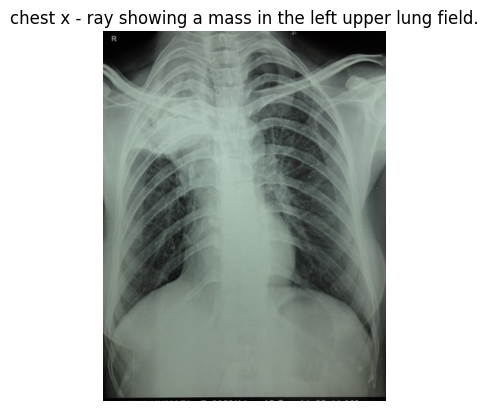

In [ ]:
import random
import matplotlib.pyplot as plt


# Get a list of all image files in the test directory
test_image_dir = '/content/drive/MyDrive/roco-content/test/images'
test_image_files = [f for f in os.listdir(test_image_dir) if os.path.isfile(os.path.join(test_image_dir, f))]

# Select a random image file
random_image_file = random.choice(test_image_files)

# Load the selected image
image_path = os.path.join(test_image_dir, random_image_file)
image = Image.open(image_path).convert("RGB")

# Preprocess image and generate caption
inputs = processor(images=image, return_tensors="pt").to(device)
generated_ids = model.generate(pixel_values=inputs.pixel_values, max_length=128)

# Decode the generated caption
generated_caption = processor.decode(generated_ids[0], skip_special_tokens=True)

# Display image and caption
plt.imshow(image)
plt.title(generated_caption)  # Set the caption as the title
plt.axis('off')  # Hide axes
plt.show()

In [ ]:
!pip install datasets transformers[sentencepiece]

In [ ]:
!pip install datasets --upgrade

In [ ]:
!pip install rouge-score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24935 sha256=e4219a53c0b34e895ee51c443b293091205cb74e06a62c4c1b53e34e7814dd1b
  Stored in directory: /root/.cache/pip/wheels/5f/dd/89/461065a73be61a532ff8599a28e9beef17985c9e9c31e541b4
Successfully built rouge-score


In [ ]:
!pip install evaluate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 8.2 MB/s eta 0:00:00


MODEL EVALUATION

In [ ]:
import evaluate

# Load a metric for evaluation
metric = evaluate.load("meteor")  # Replace "meteor" with the desired metric, e.g., "rouge", "bert_score", etc.

# Example usage
predictions = ["this is a test caption"]
references = ["this is the ground truth caption"]

# Compute the metric
results = metric.compute(predictions=predictions, references=references)
print(results)


{'meteor': 0.43314500941619577}


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
predictions = []
references = []

for batch in test_dataloader:
    pixel_values = batch['pixel_values'].to(device)
    ground_truth_captions = batch['caption']  # Retrieve ground truth captions

    with torch.no_grad():
        generated_tokens = model.generate(pixel_values=pixel_values, max_length=128)
        generated_captions = [processor.decode(token, skip_special_tokens=True) for token in generated_tokens]

    predictions.extend(generated_captions)
    references.extend(ground_truth_captions)

# Example metric evaluation (e.g., METEOR)
metric = evaluate.load("meteor")
results = metric.compute(predictions=predictions, references=references)
print(f"Evaluation Results: {results}")


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Evaluation Results: {'meteor': 0.15034211631941796}


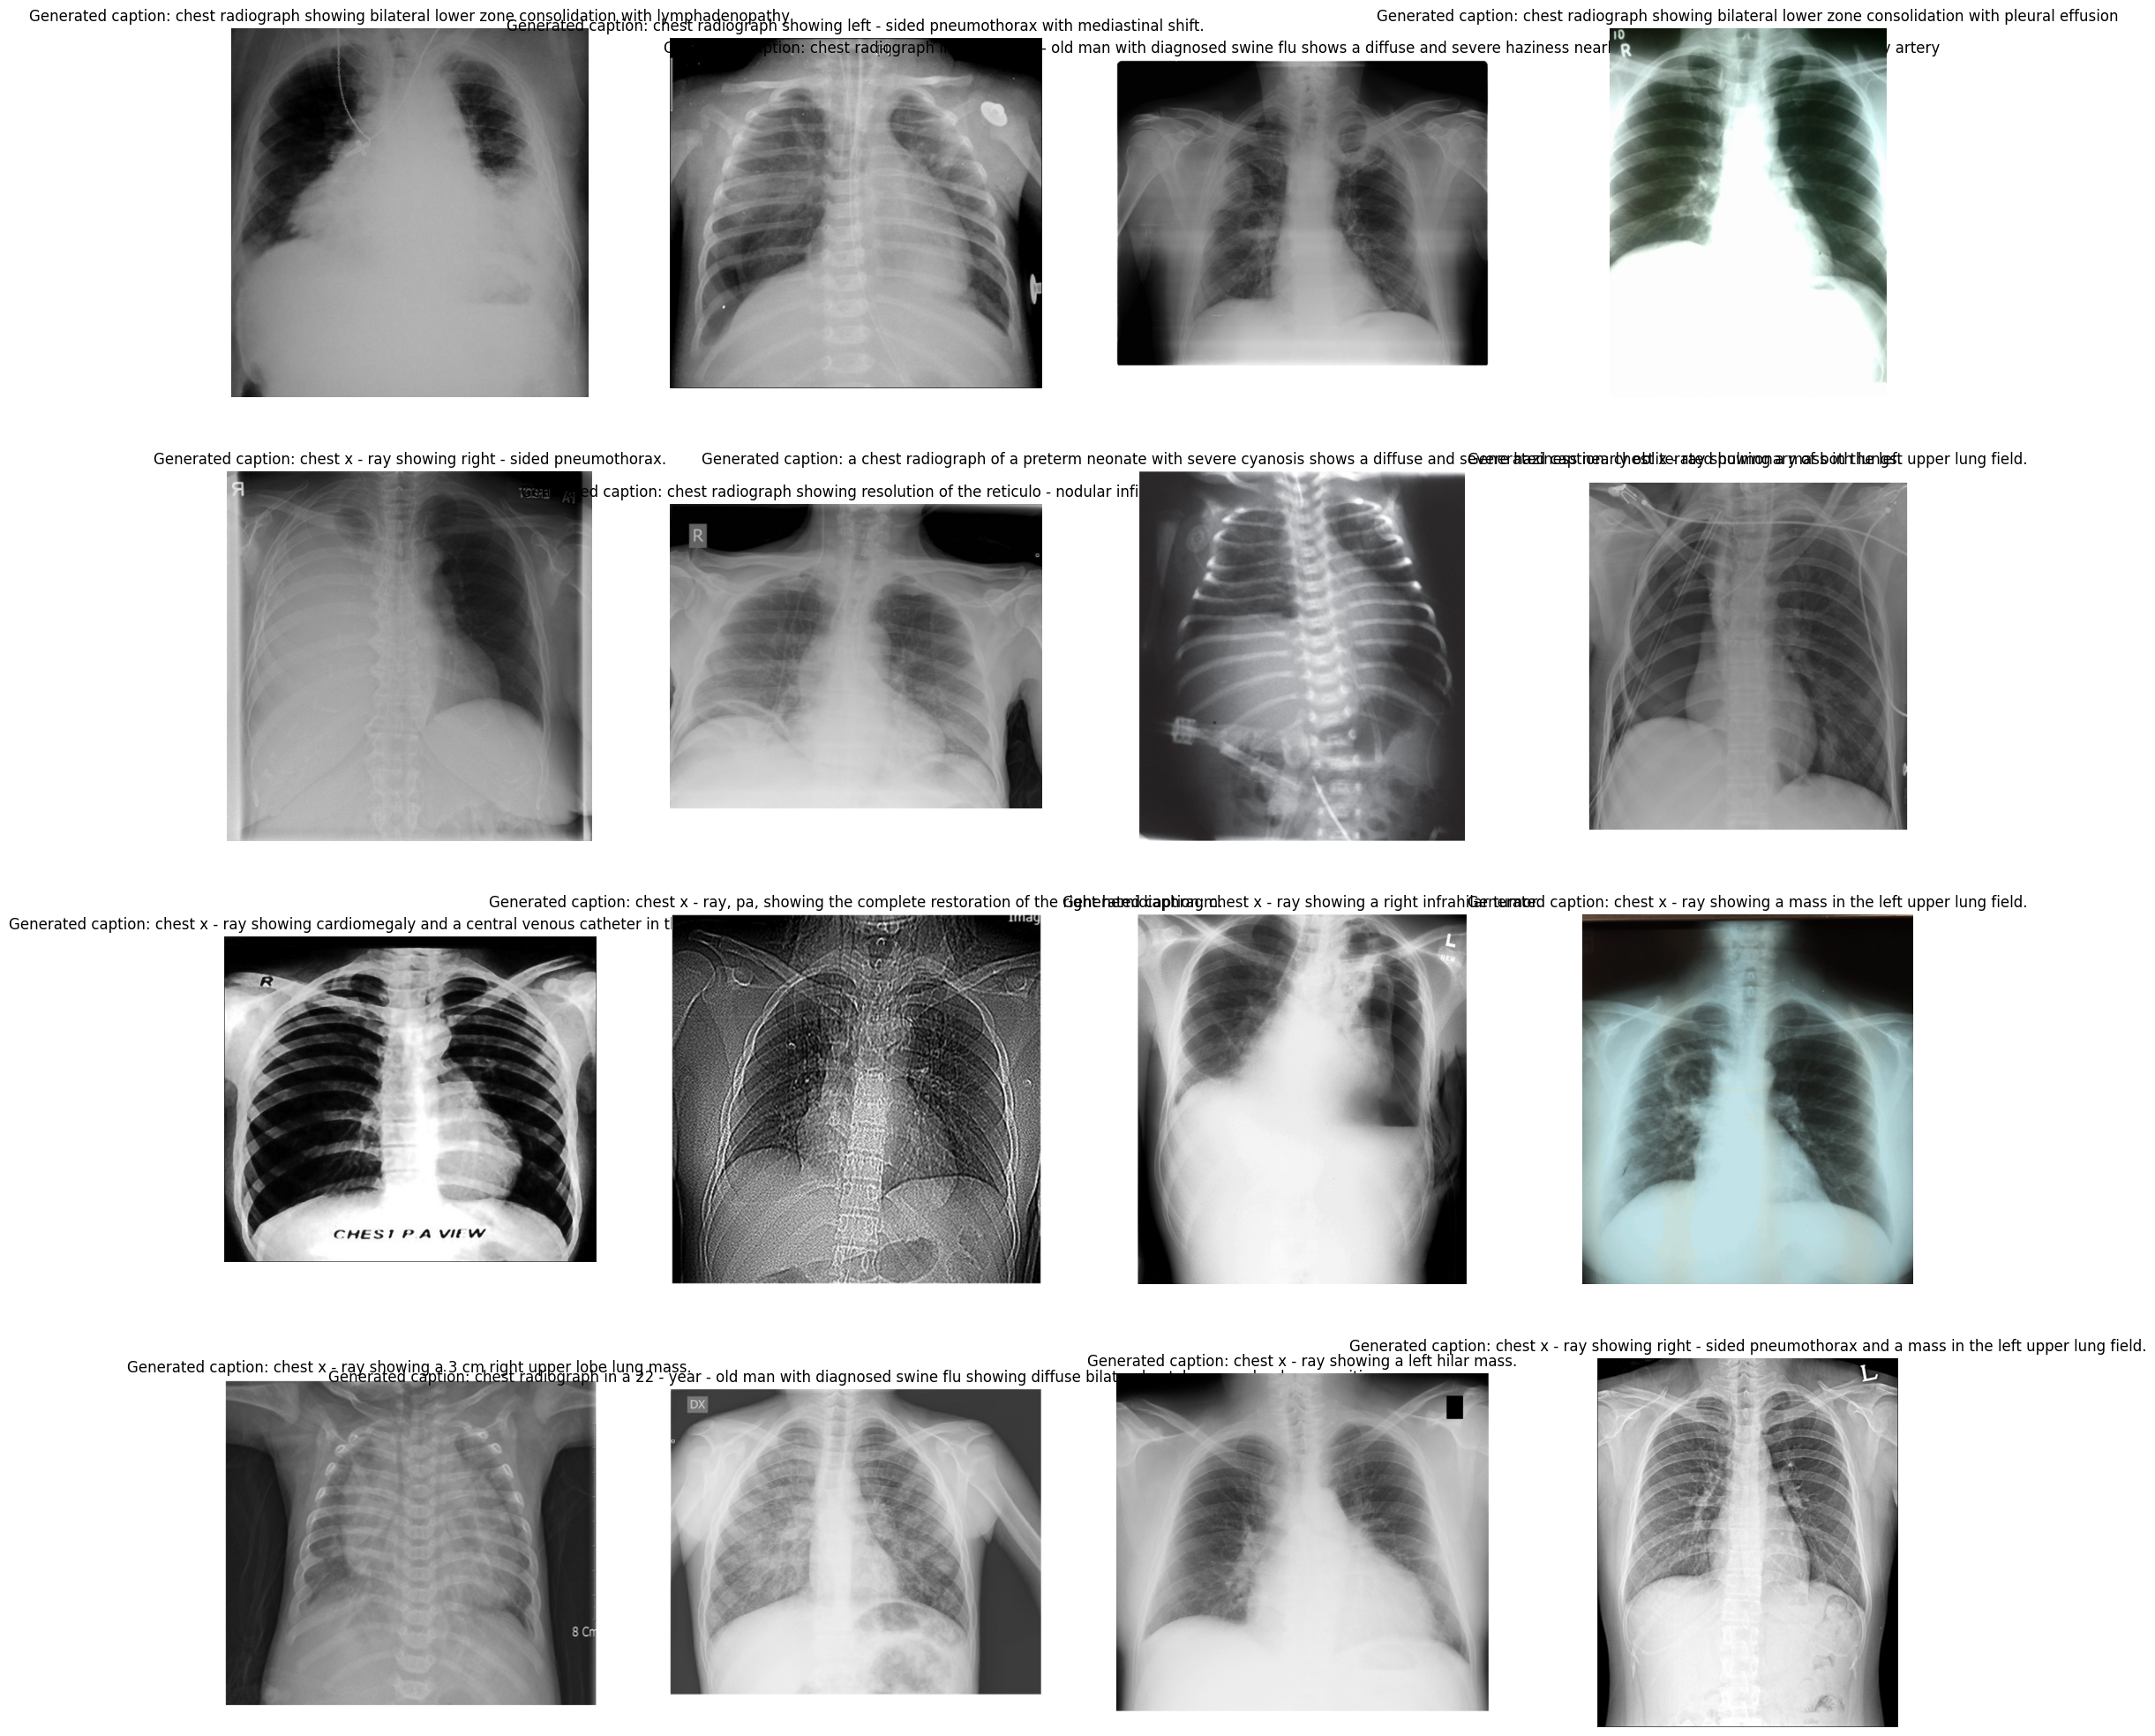

In [ ]:
import random
import matplotlib.pyplot as plt
import os
from PIL import Image

# ... (other imports and code)

# Get a list of all image files in the test directory
test_image_dir = '/content/drive/MyDrive/roco-content/test/images'
test_image_files = [f for f in os.listdir(test_image_dir) if os.path.isfile(os.path.join(test_image_dir, f))]

# Select 16 random image files
num_samples = 16
random_image_files = random.sample(test_image_files, num_samples)

# Create a figure to display the images
fig = plt.figure(figsize=(25, 25))

# Loop through the selected images and generate captions
for i, image_file in enumerate(random_image_files):
    # Load the image
    image_path = os.path.join(test_image_dir, image_file)
    image = Image.open(image_path).convert("RGB")

    # Preprocess and generate caption
    inputs = processor(images=image, return_tensors="pt").to(device)
    generated_ids = model.generate(pixel_values=inputs.pixel_values, max_length=128)
    generated_caption = processor.decode(generated_ids[0], skip_special_tokens=True)

    # Display image and caption
    fig.add_subplot(4, 4, i + 1)  # Create a subplot for each image
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Generated caption: {generated_caption}")

plt.show()

SAVING MODEL

In [ ]:
# Save the trained model
model.save_pretrained("/content/drive/MyDrive/roco-content/saved_model")
processor.save_pretrained("/content/drive/MyDrive/roco-content/saved_model")


[]

In [76]:
!pip install gradio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.4/320.4 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.8/94.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 112.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.3 MB/s eta 0:00:00
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 3.0.2
    Uninstalling MarkupSafe-3.0.2:
      Successfully uninstalled MarkupSafe-3.0.2


In [77]:
import gradio as gr
from transformers import AutoProcessor, BlipForConditionalGeneration
import torch
from PIL import Image

# Load your model and processor
processor = AutoProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")
model.eval()  # Set the model to evaluation mode

# Define the prediction function
def generate_caption(image: Image.Image):
    # Process the image and generate a caption
    inputs = processor(images=image, return_tensors="pt")
    out = model.generate(**inputs)
    caption = processor.decode(out[0], skip_special_tokens=True)
    return caption

# Create the Gradio interface
interface = gr.Interface(
    fn=generate_caption,
    inputs=gr.Image(type="pil"),  # Input is an image
    outputs=gr.Textbox(),         # Output is a textbox displaying the caption
    live=True
)

# Launch the interface
interface.launch()


Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3180dfa16af30a4374.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# Load your model and processor
processor = AutoProcessor.from_pretrained("/content/drive/MyDrive/roco-content/saved_model")
model = BlipForConditionalGeneration.from_pretrained("/content/drive/MyDrive/roco-content/saved_model")
model.eval()  # Set the model to evaluation mode

# Define the prediction function
def generate_caption(image: Image.Image):
    # Process the image and generate a caption
    inputs = processor(images=image, return_tensors="pt")
    out = model.generate(**inputs)
    caption = processor.decode(out[0], skip_special_tokens=True)
    return caption


# Create the Gradio interface
interface = gr.Interface(
    fn=generate_caption,
    inputs=gr.Image(type="pil"),  # Input is an image
    outputs=gr.Textbox(),         # Output is a textbox displaying the caption
    live=True
)

# Launch the interface
interface.launch()